# FAPE — Law School Admissions EDA
## Education/Legal Domain — Bar Passage Analysis

**Dataset:** Law School Admissions — Wightman (1998) LSAC, LeQuy et al. adaptation  
**Records:** 18,692  
**Target:** pass_bar — bar passage (binary)  
**Sensitive attributes:** racetxt (0=Minority, 1=White), male (0=Female, 1=Male)  
**Domain:** Education/Legal  

**Key finding:** 30.3% race gap in bar passage rates (White 92.1% vs Minority 61.8%). 8.12 point LSAT gap reflects structural educational disadvantage. 90.2% overall pass rate creates severe class imbalance — FAPE Stage 2 uses equalized odds not accuracy.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lawschool_loader import load_law_school

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

RACE_LABELS = {0: 'Minority', 1: 'White'}
SEX_LABELS = {0.0: 'Female', 1.0: 'Male'}
print('Imports complete')

Imports complete


In [2]:
dataset = load_law_school()
data = dataset['law_school']
df = pd.concat([data['X'], data['y']], axis=1)
df.columns = list(data['X'].columns) + ['label']
df['race_label'] = df['racetxt'].map(RACE_LABELS)
df['sex_label'] = df['male'].map(SEX_LABELS)
print(f'Shape: {df.shape}')
print(f'Pass rate: {df["label"].mean():.1%}')
print(f'Race: {df["race_label"].value_counts().to_dict()}')

Loading Law School Admissions dataset via FairGround...


[21:43:31] INFO     Loading cached dataset from cache/datasets/law_school_lequy.parquet              ]8;id=632054;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=326792;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

           INFO     Loading cached dataset from cache/datasets/law_school_lequy.parquet              ]8;id=42320;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=785052;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

  ✓ law_school_admissions: 18,692 rows | 11 features | sensitive: ['racetxt', 'male'] | positive rate: 0.902
Shape: (18692, 14)
Pass rate: 90.2%
Race: {'White': 17491, 'Minority': 1201}


## 1. Label Distribution — Severe Class Imbalance

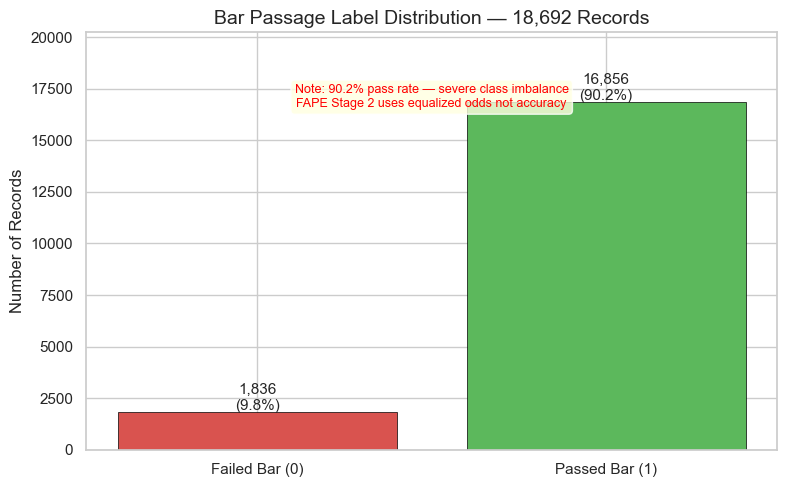

In [3]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['Failed Bar (0)','Passed Bar (1)'], label_counts.values,
              color=['#d9534f','#5cb85c'], edgecolor='black', linewidth=0.5)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({pct:.1%})', ha='center', fontsize=11)
ax.set_title('Bar Passage Label Distribution — 18,692 Records', fontsize=14)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, max(label_counts.values)*1.2)
ax.text(0.5, 0.82, 'Note: 90.2% pass rate — severe class imbalance\nFAPE Stage 2 uses equalized odds not accuracy',
        transform=ax.transAxes, ha='center', fontsize=9, color='red',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Race Distribution and Pass Rate — 30.3% Gap

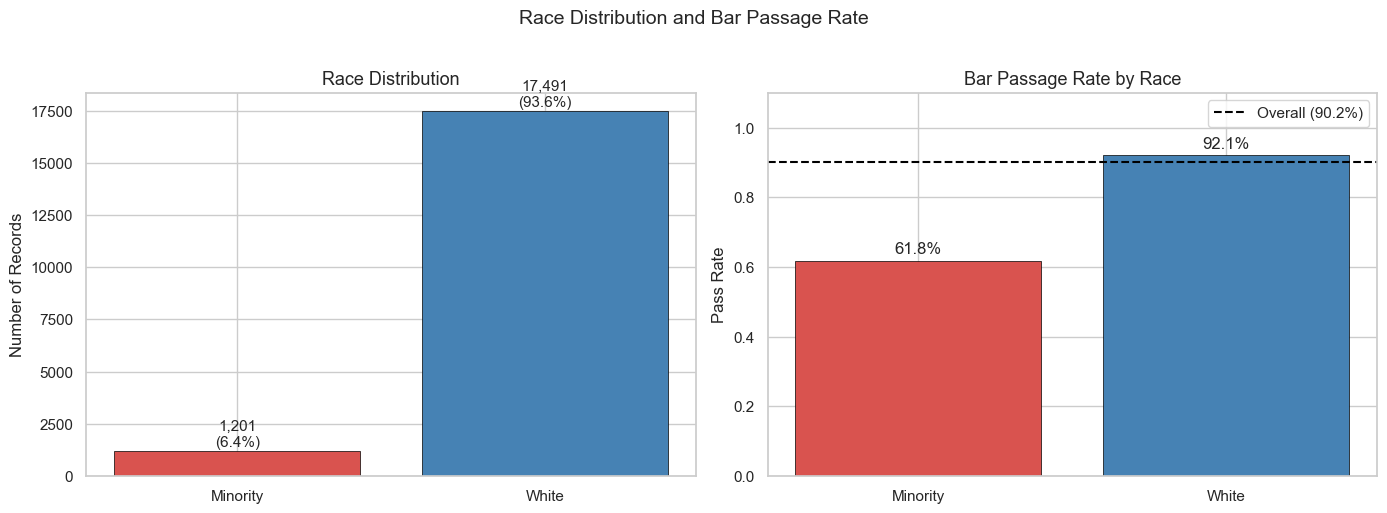

Race gap: 30.3% — largest race gap in any FAPE dataset


In [4]:
race_stats = df.groupby('race_label').agg(count=('label','count'), pass_rate=('label','mean')).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))
colors = ['#d9534f','steelblue']

ax1.bar(race_stats['race_label'], race_stats['count'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Race Distribution', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(race_stats.iterrows()):
    ax1.text(i, row['count']+200, f'{int(row["count"]):,}\n({row["count"]/len(df):.1%})', ha='center', fontsize=11)

ax2.bar(race_stats['race_label'], race_stats['pass_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Bar Passage Rate by Race', fontsize=13)
ax2.set_ylabel('Pass Rate')
ax2.set_ylim(0, 1.1)
ax2.legend()
for i, (_, row) in enumerate(race_stats.iterrows()):
    ax2.text(i, row['pass_rate']+0.02, f'{row["pass_rate"]:.1%}', ha='center', fontsize=12)

plt.suptitle('Race Distribution and Bar Passage Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_race_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
w = race_stats.loc[race_stats['race_label']=='White','pass_rate'].values[0]
m = race_stats.loc[race_stats['race_label']=='Minority','pass_rate'].values[0]
print(f'Race gap: {abs(w-m):.1%} — largest race gap in any FAPE dataset')

## 3. Sex Distribution and Pass Rate

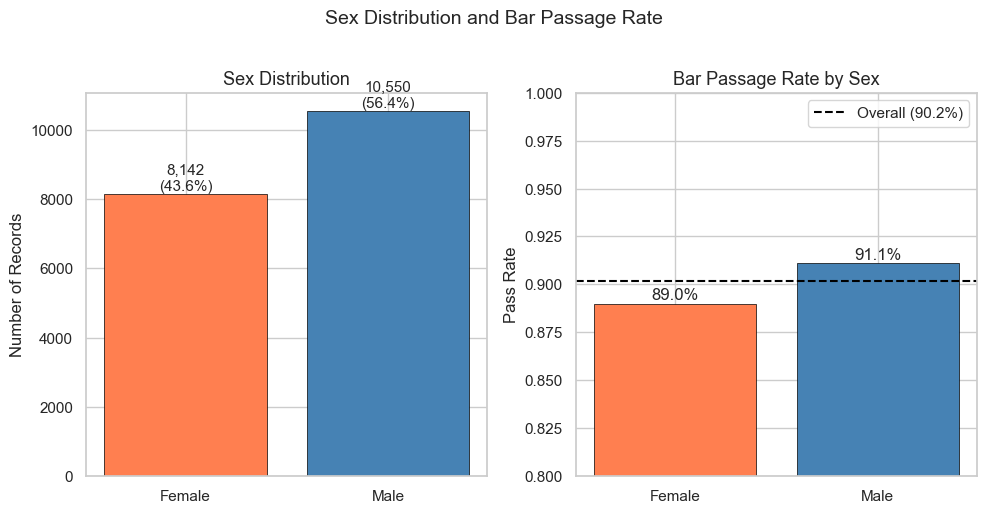

Sex gap only 2.1% — race is primary fairness concern in this dataset


In [5]:
sex_stats = df.groupby('sex_label').agg(count=('label','count'), pass_rate=('label','mean')).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

ax1.bar(sex_stats['sex_label'], sex_stats['count'], color=['coral','steelblue'], edgecolor='black', linewidth=0.5)
ax1.set_title('Sex Distribution', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax1.text(i, row['count']+100, f'{int(row["count"]):,}\n({row["count"]/len(df):.1%})', ha='center', fontsize=11)

ax2.bar(sex_stats['sex_label'], sex_stats['pass_rate'], color=['coral','steelblue'], edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Bar Passage Rate by Sex', fontsize=13)
ax2.set_ylabel('Pass Rate')
ax2.set_ylim(0.8, 1.0)
ax2.legend()
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax2.text(i, row['pass_rate']+0.002, f'{row["pass_rate"]:.1%}', ha='center', fontsize=12)

plt.suptitle('Sex Distribution and Bar Passage Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sex gap only 2.1% — race is primary fairness concern in this dataset')

## 4. LSAT Score Distribution by Race — 8.12 Point Gap

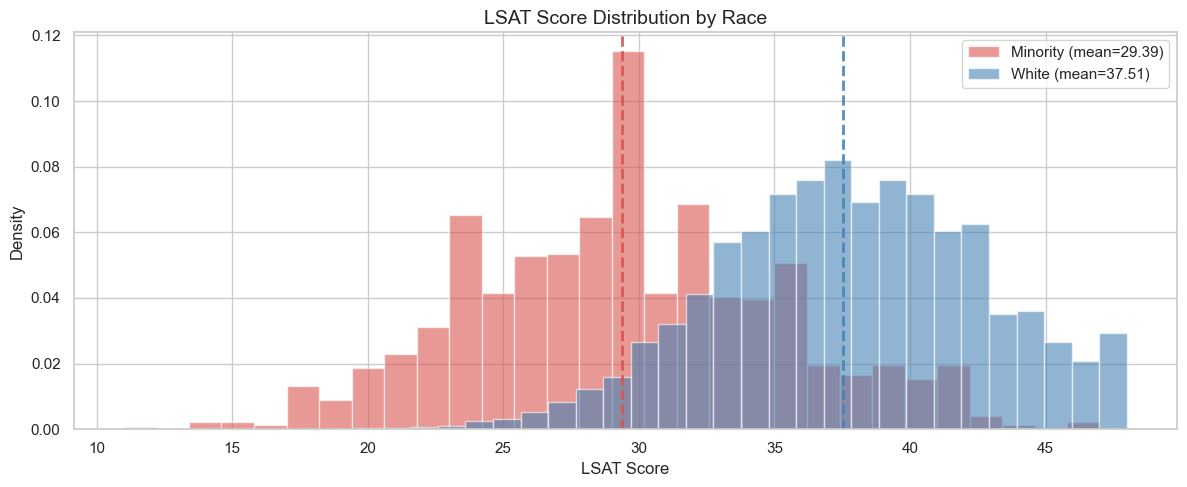

White mean LSAT: 37.51 | Minority mean LSAT: 29.39 | Gap: 8.12


In [6]:
fig, ax = plt.subplots(figsize=(12,5))
for race, color in [('Minority','#d9534f'),('White','steelblue')]:
    subset = df[df['race_label']==race]['lsat']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'{race} (mean={subset.mean():.2f})', density=True)
    ax.axvline(x=subset.mean(), color=color, linestyle='--', linewidth=2, alpha=0.9)
ax.set_title('LSAT Score Distribution by Race', fontsize=14)
ax.set_xlabel('LSAT Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_lsat_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
w_lsat = df[df['race_label']=='White']['lsat'].mean()
m_lsat = df[df['race_label']=='Minority']['lsat'].mean()
print(f'White mean LSAT: {w_lsat:.2f} | Minority mean LSAT: {m_lsat:.2f} | Gap: {w_lsat-m_lsat:.2f}')

## 5. Undergraduate GPA by Race

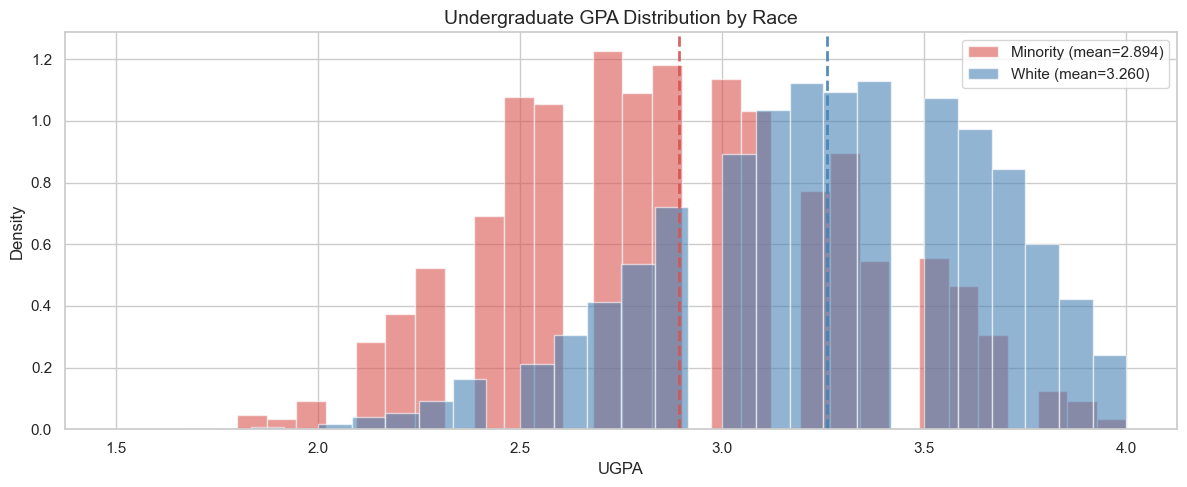

White mean UGPA: 3.260 | Minority mean UGPA: 2.894 | Gap: 0.366


In [7]:
fig, ax = plt.subplots(figsize=(12,5))
for race, color in [('Minority','#d9534f'),('White','steelblue')]:
    subset = df[df['race_label']==race]['ugpa']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'{race} (mean={subset.mean():.3f})', density=True)
    ax.axvline(x=subset.mean(), color=color, linestyle='--', linewidth=2, alpha=0.9)
ax.set_title('Undergraduate GPA Distribution by Race', fontsize=14)
ax.set_xlabel('UGPA')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_ugpa_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
w_ugpa = df[df['race_label']=='White']['ugpa'].mean()
m_ugpa = df[df['race_label']=='Minority']['ugpa'].mean()
print(f'White mean UGPA: {w_ugpa:.3f} | Minority mean UGPA: {m_ugpa:.3f} | Gap: {w_ugpa-m_ugpa:.3f}')

## 6. School Tier vs Pass Rate

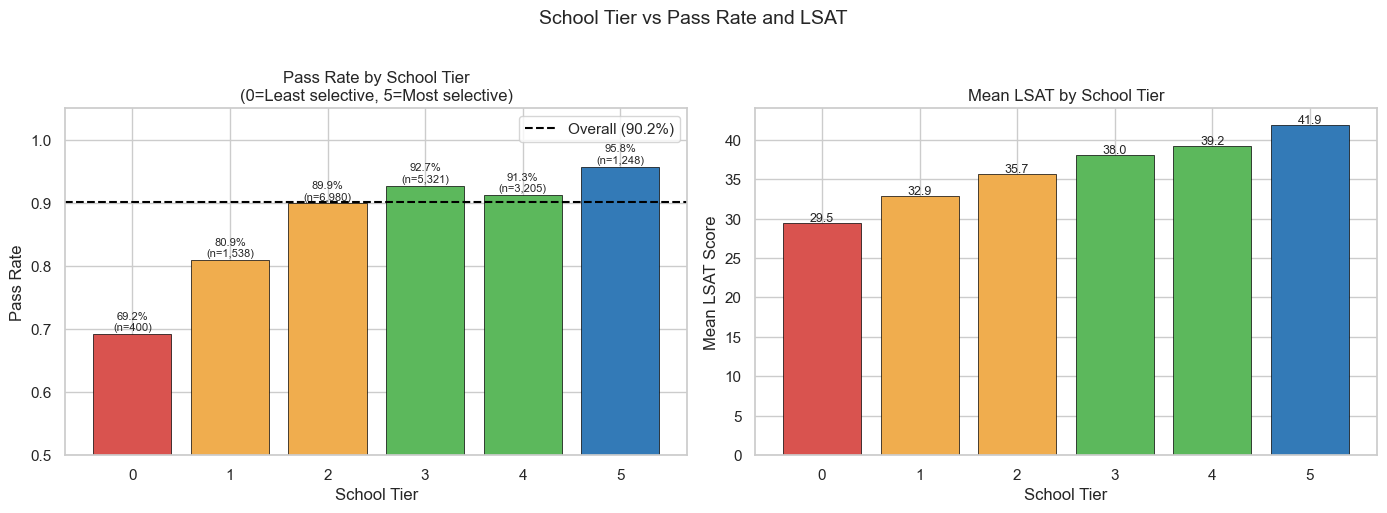

In [8]:
tier_stats = df.groupby('tier').agg(count=('label','count'), pass_rate=('label','mean'), mean_lsat=('lsat','mean')).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))
colors = ['#d9534f','#f0ad4e','#f0ad4e','#5cb85c','#5cb85c','#337ab7']

ax1.bar(tier_stats['tier'].astype(int), tier_stats['pass_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax1.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax1.set_title('Pass Rate by School Tier\n(0=Least selective, 5=Most selective)', fontsize=12)
ax1.set_xlabel('School Tier')
ax1.set_ylabel('Pass Rate')
ax1.set_ylim(0.5, 1.05)
ax1.legend()
for _, row in tier_stats.iterrows():
    ax1.text(int(row['tier']), row['pass_rate']+0.005,
             f'{row["pass_rate"]:.1%}\n(n={int(row["count"]):,})', ha='center', fontsize=8)

ax2.bar(tier_stats['tier'].astype(int), tier_stats['mean_lsat'], color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Mean LSAT by School Tier', fontsize=12)
ax2.set_xlabel('School Tier')
ax2.set_ylabel('Mean LSAT Score')
for _, row in tier_stats.iterrows():
    ax2.text(int(row['tier']), row['mean_lsat']+0.2, f'{row["mean_lsat"]:.1f}', ha='center', fontsize=9)

plt.suptitle('School Tier vs Pass Rate and LSAT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Family Income vs Pass Rate

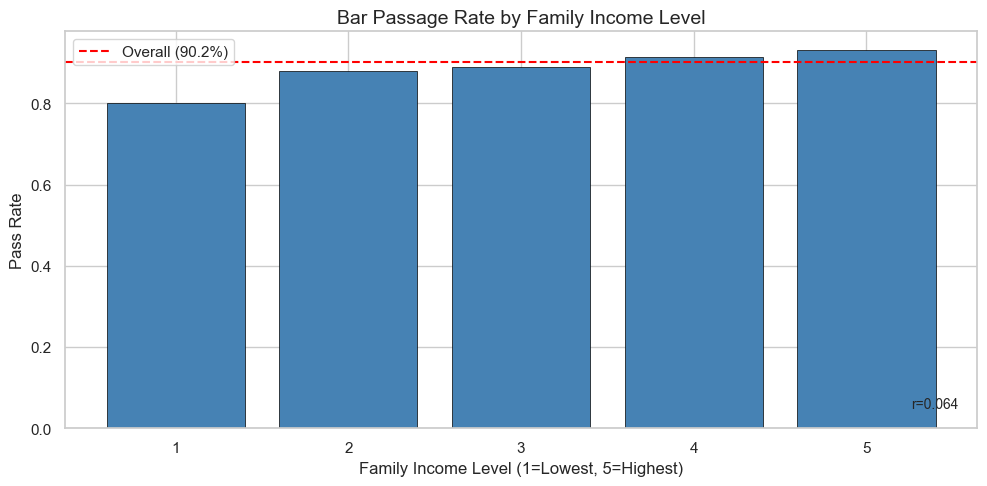

Family income correlation: 0.064 — weaker than race (r=0.250)


In [9]:
fam_stats = df.groupby('fam_inc').agg(count=('label','count'), pass_rate=('label','mean')).reset_index()

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(fam_stats['fam_inc'], fam_stats['pass_rate'], color='steelblue', edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Bar Passage Rate by Family Income Level', fontsize=14)
ax.set_xlabel('Family Income Level (1=Lowest, 5=Highest)')
ax.set_ylabel('Pass Rate')
ax.legend()
corr = df['fam_inc'].corr(df['label'])
ax.text(0.98, 0.05, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_family_income.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Family income correlation: {corr:.3f} — weaker than race (r=0.250)')

## 8. LSAT vs UGPA — Racial Group Separation

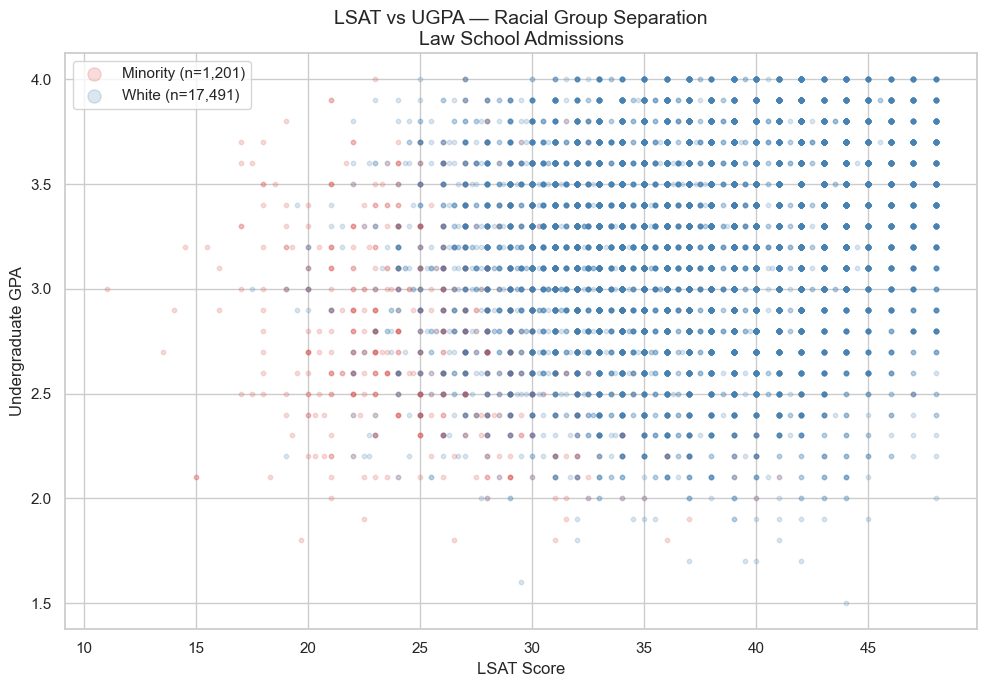

Clear racial group separation in LSAT-UGPA space
Minority applicants cluster in lower-left — structural educational disadvantage


In [10]:
fig, ax = plt.subplots(figsize=(10,7))
for race, color in [('Minority','#d9534f'),('White','steelblue')]:
    subset = df[df['race_label']==race]
    ax.scatter(subset['lsat'], subset['ugpa'], alpha=0.2, s=10,
               color=color, label=f'{race} (n={len(subset):,})')
ax.set_title('LSAT vs UGPA — Racial Group Separation\nLaw School Admissions', fontsize=14)
ax.set_xlabel('LSAT Score')
ax.set_ylabel('Undergraduate GPA')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_lsat_ugpa_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Clear racial group separation in LSAT-UGPA space')
print('Minority applicants cluster in lower-left — structural educational disadvantage')

## 9. Intersectional Analysis — Race × Sex

Note: Minority group n=1,201 (6.4%) — intersectional cells have high variance.

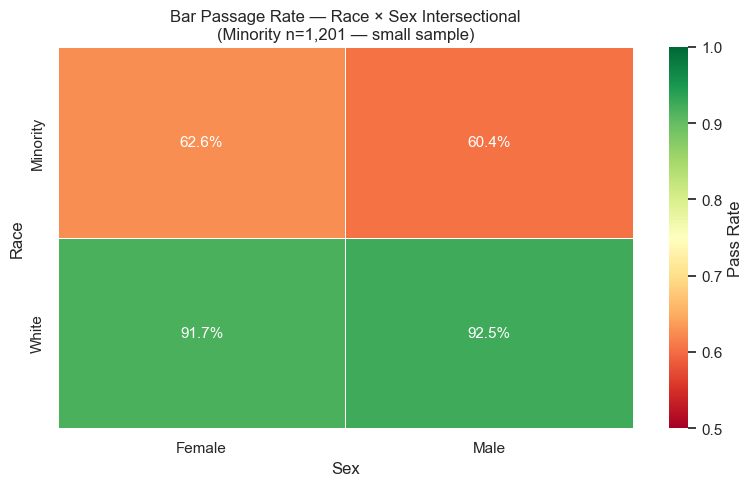

Sample sizes per cell:
sex_label   Female   Male
race_label               
Minority       749    452
White         7393  10098


In [11]:
pivot = df.groupby(['race_label','sex_label'])['label'].mean().unstack()
pivot_n = df.groupby(['race_label','sex_label'])['label'].count().unstack()

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0, cbar_kws={'label':'Pass Rate'})
ax.set_title('Bar Passage Rate — Race × Sex Intersectional\n(Minority n=1,201 — small sample)', fontsize=12)
ax.set_xlabel('Sex')
ax.set_ylabel('Race')
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_intersectional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample sizes per cell:')
print(pivot_n)

## 10. Feature Correlations with Pass Rate

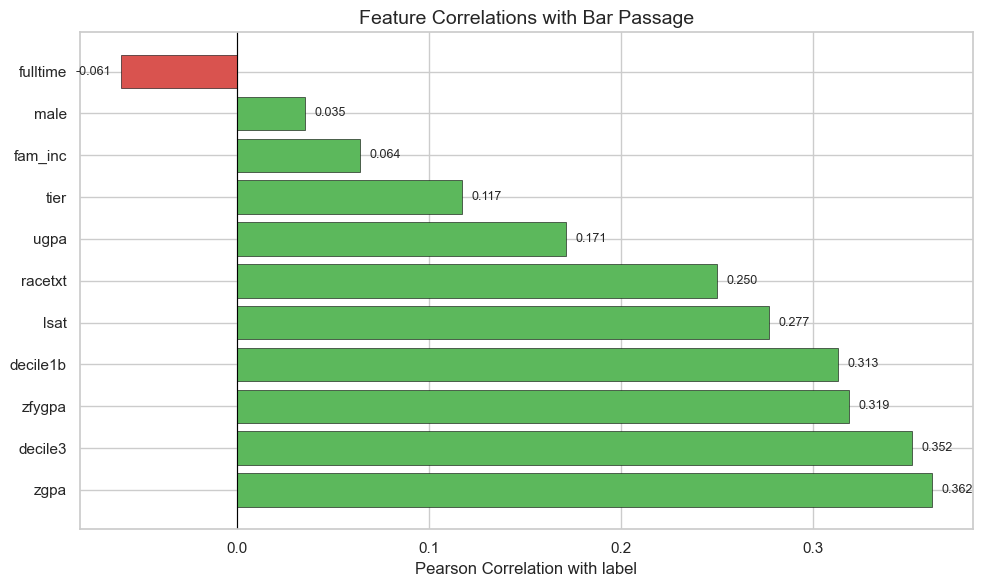

zgpa strongest predictor (r=0.362) | racetxt r=0.250 — race is 5th strongest


In [12]:
numeric_cols = ['lsat','ugpa','zfygpa','zgpa','decile1b','decile3',
                'fulltime','fam_inc','male','racetxt','tier']
correlations = df[numeric_cols+['label']].corr()['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#5cb85c' if v>0 else '#d9534f' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Bar Passage', fontsize=14)
ax.set_xlabel('Pearson Correlation with label')
for i, (feat, val) in enumerate(correlations.items()):
    offset = 0.005 if val>=0 else -0.005
    ha = 'left' if val>=0 else 'right'
    ax.text(val+offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('zgpa strongest predictor (r=0.362) | racetxt r=0.250 — race is 5th strongest')

## 11. Race Gap Summary — Key Fairness Finding

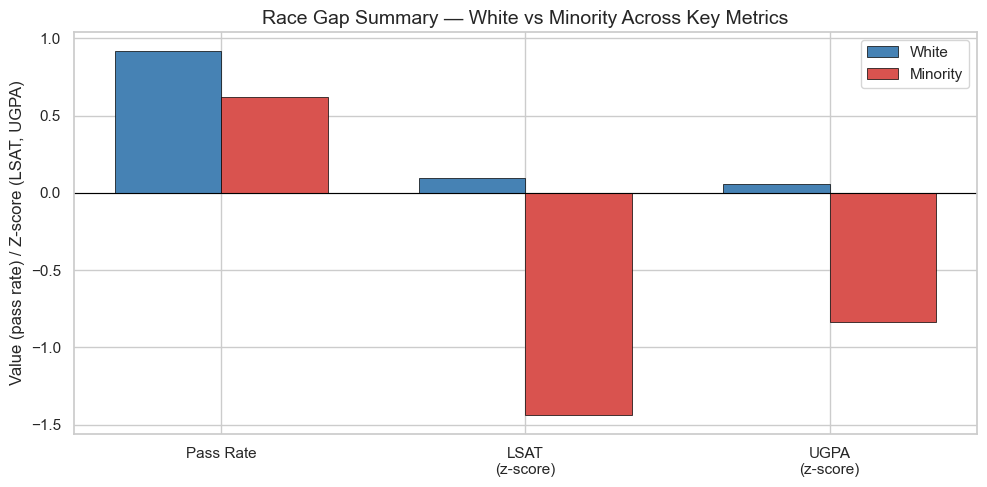

In [13]:
metrics = ['Pass Rate', 'LSAT\n(z-score)', 'UGPA\n(z-score)']
white_vals = [
    df[df['race_label']=='White']['label'].mean(),
    (df[df['race_label']=='White']['lsat'].mean()-df['lsat'].mean())/df['lsat'].std(),
    (df[df['race_label']=='White']['ugpa'].mean()-df['ugpa'].mean())/df['ugpa'].std()
]
minority_vals = [
    df[df['race_label']=='Minority']['label'].mean(),
    (df[df['race_label']=='Minority']['lsat'].mean()-df['lsat'].mean())/df['lsat'].std(),
    (df[df['race_label']=='Minority']['ugpa'].mean()-df['ugpa'].mean())/df['ugpa'].std()
]

x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([i-width/2 for i in x], white_vals, width, label='White', color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar([i+width/2 for i in x], minority_vals, width, label='Minority', color='#d9534f', edgecolor='black', linewidth=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Race Gap Summary — White vs Minority Across Key Metrics', fontsize=14)
ax.set_ylabel('Value (pass rate) / Z-score (LSAT, UGPA)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/lawschool_race_gap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Key Fairness Observations

**Race gap — 30.3%:** White pass rate 92.1% vs Minority 61.8%. Largest race gap in any FAPE dataset. Reflects compounding disadvantages across LSAT, UGPA, school tier, and family income.

**LSAT gap — 8.12 points:** White mean 37.51 vs Minority 29.39. LSAT correlation with pass rate r=0.277. Reflects structural educational disadvantage.

**Class imbalance — 90.2% pass rate:** Standard accuracy misleading. FAPE Stage 2 uses equalized odds difference.

**School tier effect:** Tier 0 passes at 69.2%, Tier 5 at 95.8%. Minority applicants cluster in lower tiers — institutional hierarchy compounds individual disadvantage.

**Sex gap is small (2.1%):** Race is the primary fairness concern.

**Minority sample caveat (n=1,201, 6.4%):** Small relative to White (n=17,491). FAPE Stage 2 reports confidence intervals for minority group metrics.